<a href="https://colab.research.google.com/github/broistg/ML-Assignment-DNAC1/blob/main/notebooks/BTL2_deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0.&nbsp;User manual

This Google Colab file implements a deep learning pipeline for a text dataset (20 Newsgroups). To run this notebook, do the following:
1. First click the Colab `Run all` button. Due to some library conflicts you will need to restart session in the first cell below.
2. After that click `Run all` again (library installation and dataset loading are automated).
3. Select the confiuration you want in the last cell (default: fine tuning DistilBERT model).
4. After that click `Run Pipeline` in the last cell. The pipeline will run according to your configuration.

If you want to rerun the pipeline with another configuration, you only need to click `Run Pipeline` again after selecting your config. If you want a cleaner look you should also rerun the last cell before setting a new config.

# 1.&nbsp;Prepare the necessary data and libraries

## 1.1.&nbsp;Verify and install necessary libraries

In [1]:
# Require SESSION RESTART for first time running
%pip install gensim
# After restarting, press Run all again

In [2]:
# Verify required libraries
import sys
import subprocess

def pip_install(packages):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + packages)

pip_install(["scikit-learn", "pandas", "tqdm", "matplotlib", "seaborn", "plotly", "wget",
             "WordCloud", "transformers", "datasets", "sentencepiece", "tokenizers", "torchtext"])

# Import libraries
import wget
import os, random, math, time, json
from pprint import pprint
from collections import Counter
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_files
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, classification_report, precision_recall_fscore_support, confusion_matrix
import torch
from torch.utils.data import DataLoader, Dataset as TorchDataset
import torch.nn as nn

# Ensure ipywidgets extension works in colab notebook
try:
    import google.colab
    # Colab already supports ipywidgets; nothing special required
except Exception:
    pass

# Ensure reproducibility
RND = 42
random.seed(RND); np.random.seed(RND); torch.manual_seed(RND)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RND)

# device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## 1.2.&nbsp;Download and store the dataset

In [3]:
url = "http://qwone.com/~jason/20Newsgroups/20news-18828.tar.gz"
filename = "20news-18828.tar.gz"
folder = "20news-18828"

if not os.path.exists(folder):
    if not os.path.exists(filename):
        print("Downloading file .tar.gz...")
        !wget -q {url} -O {filename}
        print("Done!")
    else:
        print("File .tar.gz already exists.")

    print("Extracting")
    !tar -xzf {filename}
    print("Done!")
else:
    print("Dataset already exists.")

# Load dataset
dataset = load_files("20news-18828", encoding="latin1")

print("\nNumber of documents:", len(dataset.data))
print("Number of classes:", len(dataset.target_names))

Done!
Extracting
Done!

Number of documents: 18828
Number of classes: 20


In [4]:
import re
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|[\w\.-]+@[\w\.-]+|\d+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return " ".join(tokens)

dataset_cleaned = [clean_text(doc) for doc in dataset.data]

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# 2.&nbsp;Exploratory Data Analysis (EDA)

In [5]:
# Print the first 3 documents
for i in range(3):
    print(f"Document {i+1}")
    print("Target:", dataset.target_names[dataset.target[i]])
    print(dataset.data[i])

Document 1
Target: comp.graphics
From: haston@utkvx.utk.edu (Haston, Donald Wayne)
Subject: Church related graphics

I am looking for some good quality graphics files which are
suitable for use in church-related presentations. I prefer vector,
but anything would be helpful.

If you know of bulletin boards which have collections of this nature, or
commercial products, please inform me by email:

HASTON@UTKVX.UTK.EDU

Wayne Haston




Document 2
Target: comp.graphics
From: jr0930@eve.albany.edu (REGAN JAMES P)
Subject: Re: Pascal-Fractals

Apparently, my editor didn't do what I wanted it to do, so I'll try again.

i'm looking for any programs or code to do simple animation and/or
drawing using fractals in TurboPascal for an IBM
              Thanks in advance
-- 
 |||||||||||   		 	   ||||||||||| 
_|||||||||||_______________________|||||||||||_      jr0930@eve.albany.edu
-|||||||||||-----------------------|||||||||||-     jr0930@Albnyvms.bitnet
 |||||||||||  GO HEAVY OR GO HOME  ||||||||

Value counts for target:
rec.sport.hockey            999
soc.religion.christian      997
rec.sport.baseball          994
rec.motorcycles             994
sci.crypt                   991
sci.med                     990
rec.autos                   990
sci.space                   987
comp.os.ms-windows.misc     985
comp.sys.ibm.pc.hardware    982
sci.electronics             981
comp.windows.x              980
comp.graphics               973
misc.forsale                972
comp.sys.mac.hardware       961
talk.politics.mideast       940
talk.politics.guns          910
alt.atheism                 799
talk.politics.misc          775
talk.religion.misc          628
Name: count, dtype: int64


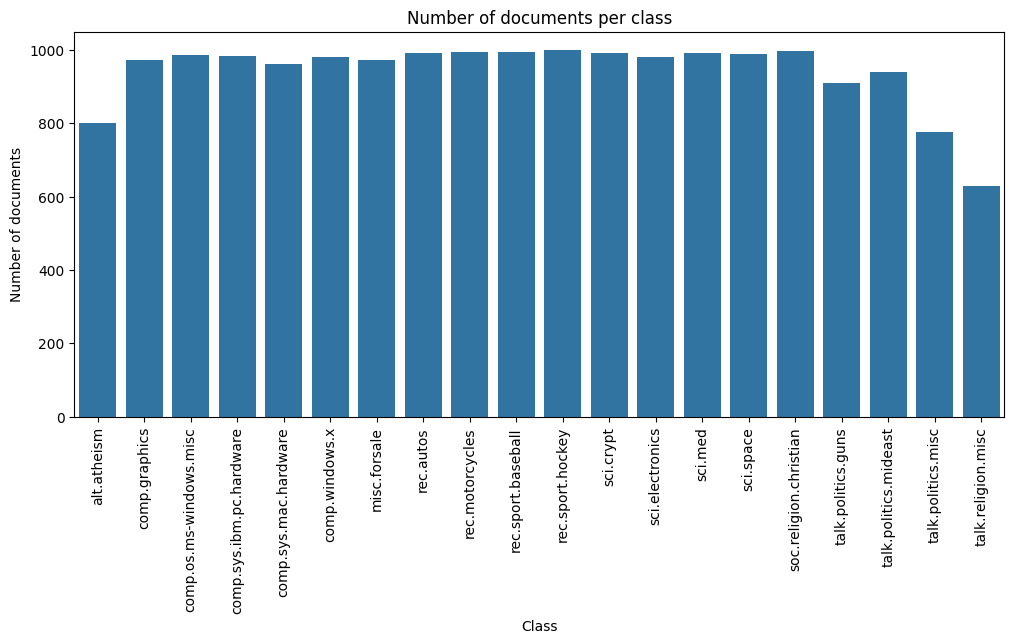

In [6]:
# Value counts for target
target_series = pd.Series(dataset.target)
target_series_named = target_series.map(lambda x: dataset.target_names[x])

print("Value counts for target:")
print(target_series_named.value_counts())

counts = Counter(dataset.target)

plt.figure(figsize=(12,5))
sns.barplot(x=list(counts.keys()), y=list(counts.values()))
plt.xticks(range(len(dataset.target_names)), dataset.target_names, rotation=90)
plt.title("Number of documents per class")
plt.ylabel("Number of documents")
plt.xlabel("Class")
plt.show()

Average document length: 272.49479498619075
Median document length: 164.0
Maximum document length: 11795
Minimum document length: 5


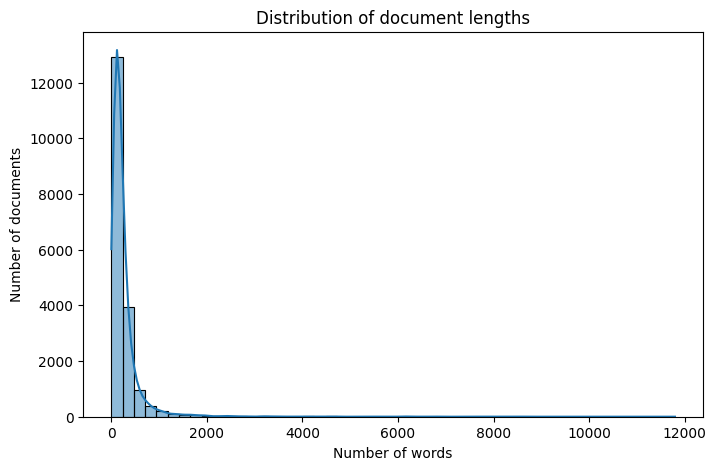

In [7]:
# Document lengths
doc_lengths = [len(doc.split()) for doc in dataset.data]

print("Average document length:", np.mean(doc_lengths))
print("Median document length:", np.median(doc_lengths))
print("Maximum document length:", np.max(doc_lengths))
print("Minimum document length:", np.min(doc_lengths))

plt.figure(figsize=(8,5))
sns.histplot(doc_lengths, bins=50, kde=True)
plt.title("Distribution of document lengths")
plt.xlabel("Number of words")
plt.ylabel("Number of documents")
plt.show()

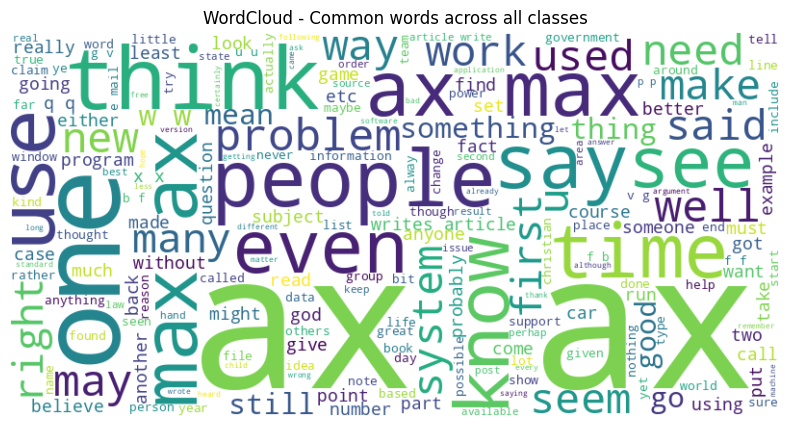

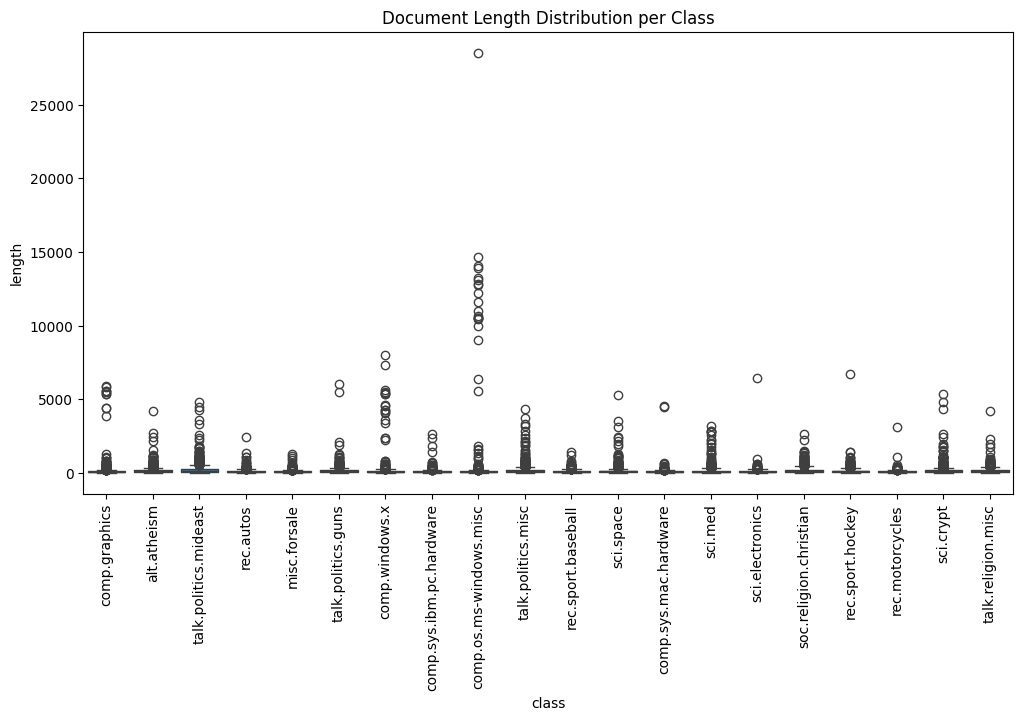

In [8]:
from wordcloud import WordCloud

text_all = " ".join(dataset_cleaned)
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=200).generate(text_all)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("WordCloud - Common words across all classes")
plt.show()

doc_lengths = [len(doc.split()) for doc in dataset_cleaned]
df_length = pd.DataFrame({"length": doc_lengths, "class": [dataset.target_names[i] for i in dataset.target]})
plt.figure(figsize=(12, 6))
sns.boxplot(x="class", y="length", data=df_length)
plt.xticks(rotation=90)
plt.title("Document Length Distribution per Class")
plt.show()

Vocabulary size (including stopwords): 170781


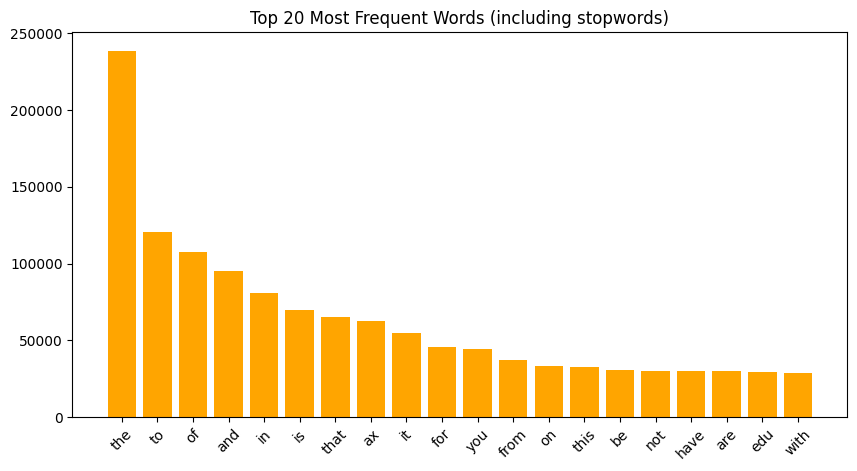

Vocabulary size (stopwords removed): 170470


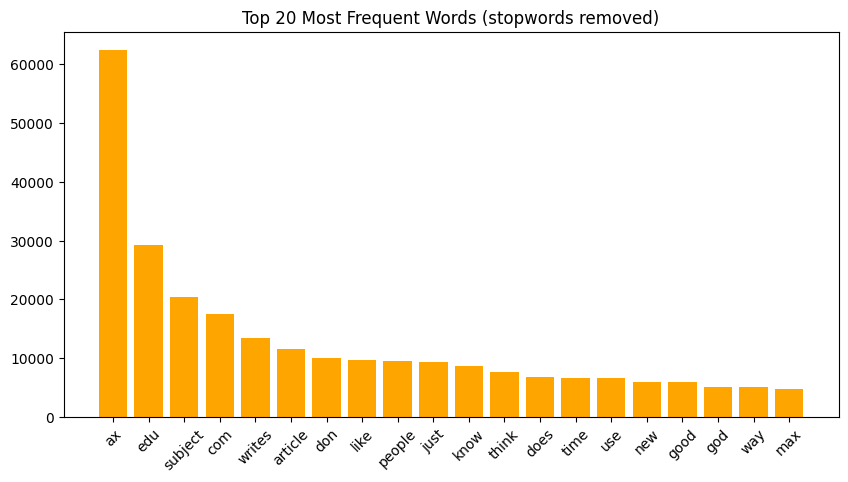

In [9]:
# Plot top 10 words and vocabulary size (including stopwords)
vectorizer = CountVectorizer(stop_words=None)
X = vectorizer.fit_transform(dataset.data)

word_counts = np.asarray(X.sum(axis=0)).ravel()
top_indices = word_counts.argsort()[::-1][:20]

vocab_1 = vectorizer.get_feature_names_out()
print(f"Vocabulary size (including stopwords): {len(vocab_1)}")

plt.figure(figsize=(10,5))
plt.bar([vocab_1[i] for i in top_indices], word_counts[top_indices], color='orange')
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words (including stopwords)")
plt.show()

# Plot top 10 words and vocabulary size (stopwords removed)
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(dataset.data)

word_counts = np.asarray(X.sum(axis=0)).ravel()
top_indices = word_counts.argsort()[::-1][:20]

vocab_2 = vectorizer.get_feature_names_out()
print(f"Vocabulary size (stopwords removed): {len(vocab_2)}")

plt.figure(figsize=(10,5))
plt.bar([vocab_2[i] for i in top_indices], word_counts[top_indices], color='orange')
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words (stopwords removed)")
plt.show()

# 3.&nbsp;Feature Extraction with Text Preprocessing

## 3.1.&nbsp;Train/Val/Test split with stratification

In [10]:
# Split dataset into train/val/test sets
X = dataset.data
# X = dataset_cleaned
y = dataset.target

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=RND, stratify=dataset.target)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=RND, stratify=y_temp)

print('Original dataset shape:', len(dataset.data))
print('Split -> Train:', len(X_train), '   Validation:', len(X_val), '   Test:', len(X_test))

Original dataset shape: 18828
Split -> Train: 13179    Validation: 2824    Test: 2825


## 3.2.&nbsp;Set up Tokenizer and Vectorizer
Depending on the UI selection, we will use whitespace tokenization + static embeddings (Word2Vec/GloVe) or transformer tokenizers + contextual embeddings.

For transformer embeddings, we use the same model as tokenizer to preserve meaning

In [11]:
# Tokenizer and static embedding loaders
from transformers import AutoTokenizer

def get_tokenizer(config):
    name = config['tokenizer']
    if name == 'whitespace':
        return None
    elif name == 'distilbert':
        return AutoTokenizer.from_pretrained('distilbert-base-uncased')
    elif name == 'bert':
        return AutoTokenizer.from_pretrained('bert-base-uncased')
    elif name == 'roberta':
        return AutoTokenizer.from_pretrained('roberta-base')
    else: # Use fine tune model
        model_name = config['model_type']
        if model_name == 'distilbert-base-uncased' or model_name == 'bert-base-uncased' or model_name == 'roberta-base':
            return AutoTokenizer.from_pretrained(model_name)
        else:
            return AutoTokenizer.from_pretrained('distilbert-base-uncased')

# Static embedding loader (gensim downloader) - used for 'glove' or 'word2vec'
def load_static_embedding(vectorizer, embed_dim=300):
    import gensim.downloader as api
    if vectorizer == 'glove':
        if embed_dim == 300:
            name = 'glove-wiki-gigaword-300'
        elif embed_dim == 100:
            name = 'glove-wiki-gigaword-100'
        else:
            name = 'glove-wiki-gigaword-300'
    elif vectorizer == 'word2vec':
        if embed_dim == 300:
            name = 'word2vec-google-news-300'
        else:
            name = 'glove-twitter-200'
    else:
        raise ValueError('Unknown static vectorizer: ' + vectorizer)
    print('Loading embedding:', name)
    model = api.load(name)
    return model

## 3.3.&nbsp;Dataset and Dataloader
We provide a Dataset wrapper for whitespace tokenization (with static embeddings) and a transformer-based dataset (using tokenizer).

In [12]:
from torch.nn.utils.rnn import pad_sequence
from collections import Counter

class TextDataset(TorchDataset):
    def __init__(self, texts, labels, tokenizer, config, vocab=None, word2idx=None):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.config = config
        self.vocab = vocab
        self.word2idx = word2idx

    def __len__(self): return len(self.texts)

    def whitespace_tokenize(self, text):
        return text.lower().split()

    def encode_whitespace(self, text):
        tokens = self.whitespace_tokenize(text)[:self.config['max_length']]
        ids = [self.word2idx.get(t, self.word2idx.get('<unk>')) for t in tokens]
        return torch.tensor(ids, dtype=torch.long)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = int(self.labels[idx])
        if self.config['tokenizer']=='whitespace':
            return self.encode_whitespace(text), label, text
        else:
            enc = self.tokenizer(text, truncation=True, padding=False, max_length=self.config['max_length'], return_tensors=None)
            return enc, label, text

def collate_whitespace(batch):
    ids = [item[0] for item in batch]
    labels = torch.tensor([item[1] for item in batch], dtype=torch.long)
    ids_padded = pad_sequence(ids, batch_first=True, padding_value=0)
    lengths = torch.tensor([len(x) for x in ids], dtype=torch.long)
    return ids_padded, lengths, labels

def collate_transformer(batch, tokenizer, config):
    texts = [item[2] for item in batch]
    labels = [item[1] for item in batch]
    out = tokenizer(texts, truncation=True, padding='longest', max_length=config['max_length'], return_tensors='pt')
    out['labels'] = torch.tensor(labels, dtype=torch.long)
    return out

# 4.&nbsp;Model Definition
We include an LSTM classifier for static embeddings and use Hugging Face AutoModelForSequenceClassification for transformer fine-tuning.

## 4.1.&nbsp;LSTM classifier

In [13]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, num_layers=1, bidirectional=True, dropout=0.3, embedding_matrix=None, freeze_embeddings=True):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if embedding_matrix is not None:
            self.embedding.weight.data.copy_(torch.tensor(embedding_matrix))
            if freeze_embeddings:
                self.embedding.weight.requires_grad = False
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True, bidirectional=bidirectional, dropout=dropout if num_layers>1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * (2 if bidirectional else 1), num_classes)

    def forward(self, input_ids, lengths=None):
        x = self.embedding(input_ids)
        if lengths is not None:
            packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
            _, (h, _) = self.lstm(packed)
        else:
            _, (h, _) = self.lstm(x)
        if self.lstm.bidirectional:
            h_cat = torch.cat([h[-1], h[-2]], dim=1)
        else:
            h_cat = h[-1]
        out = self.dropout(h_cat)
        return self.fc(out)

def build_embedding_matrix(embedding_model, word2idx, embed_dim):
    vocab_size = len(word2idx)
    matrix = np.random.normal(scale=0.01, size=(vocab_size, embed_dim)).astype(np.float32)
    for w, idx in word2idx.items():
        if w in embedding_model:
            matrix[idx] = embedding_model[w]
    matrix[0] = np.zeros((embed_dim,), dtype=np.float32)
    return matrix

## 4.2.&nbsp;Hugging Face Transformer
Define later when use in training

# 5.&nbsp;Training and Evaluation
Training loops include tqdm progress bars. We log epoch-level metrics (loss, accuracy) and collect them for Plotly visualization.

## 5.1.&nbsp;LSTM

In [14]:
# LSTM training / evaluation with tqdm and metric logging
def train_lstm(model, train_loader, val_loader, config, device):
    model.to(device)
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=config['lr'], weight_decay=config['weight_decay'])
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val = 0.0
    for epoch in range(config['epochs']):
        model.train()
        total_loss = 0.0
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{config["epochs"]}', unit='batch')
        for batch in pbar:
            input_ids, lengths, labels = batch
            input_ids = input_ids.to(device); lengths = lengths.to(device); labels = labels.to(device)
            optimizer.zero_grad()
            logits = model(input_ids, lengths)
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        train_loss = total_loss / len(train_loader)
        val_acc, val_loss = evaluate_lstm(model, val_loader, device, return_loss=True)
        history['train_loss'].append(train_loss); history['val_loss'].append(val_loss); history['val_acc'].append(val_acc)
        print(f'Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}')
        if val_acc > best_val:
            best_val = val_acc
            torch.save(model.state_dict(), 'best_lstm.pt')
    return history

def evaluate_lstm(model, data_loader, device, return_loss=False):
    model.eval()
    preds = []; truths = []
    total_loss = 0.0
    criterion = nn.CrossEntropyLoss()
    with torch.no_grad():
        for batch in tqdm(data_loader, desc='Evaluating', unit='batch'):
            input_ids, lengths, labels = batch
            input_ids = input_ids.to(device); lengths = lengths.to(device); labels = labels.to(device)
            logits = model(input_ids, lengths)
            loss = criterion(logits, labels)
            total_loss += loss.item()
            batch_preds = logits.argmax(dim=1).cpu().numpy().tolist()
            preds.extend(batch_preds); truths.extend(labels.cpu().numpy().tolist())
    acc = accuracy_score(truths, preds)
    if return_loss:
        return acc, total_loss / len(data_loader)
    else:
        report = classification_report(truths, preds, zero_division=0, target_names=dataset.target_names)
        return acc, report

## 5.2.&nbsp;Transformer fine-tuning

In [15]:
# Transformer fine-tuning using Hugging Face Trainer (with metric logging)
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding

def transform_dataset_for_hf(texts, labels, tokenizer, config):
    enc = tokenizer(texts, truncation=True, padding=True, max_length=config['max_length'])
    ds = {'input_ids': enc['input_ids'], 'attention_mask': enc['attention_mask'], 'labels': labels}
    import datasets as dslib
    return dslib.Dataset.from_dict(ds)

def train_transformer(train_texts, train_labels, val_texts, val_labels, tokenizer, config):
    model_name = config['model_type']
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(dataset.target_names))
    hf_train = transform_dataset_for_hf(train_texts, train_labels, tokenizer, config)
    hf_val = transform_dataset_for_hf(val_texts, val_labels, tokenizer, config)
    args = TrainingArguments(
        output_dir='hf_out',
        eval_strategy='epoch',
        save_strategy='epoch',
        learning_rate=config['lr'],
        warmup_steps=config['warmup_steps'],
        weight_decay=config['weight_decay'],
        per_device_train_batch_size=config['batch_size'],
        per_device_eval_batch_size=config['batch_size'],
        num_train_epochs=config['epochs'],
        load_best_model_at_end=True,
        metric_for_best_model='accuracy',
        logging_dir='hf_logs',
        logging_steps=10,
        report_to='none'
    )
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        acc = accuracy_score(labels, preds)
        prec, rec, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted', zero_division=0)
        return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}
    trainer = Trainer(
        model=model, args=args, train_dataset=hf_train, eval_dataset=hf_val,
        processing_class=tokenizer, data_collator=data_collator, compute_metrics=compute_metrics
    )
    trainer.train()
    return trainer

# 6.&nbsp;Visualization
We provide Plotly functions to show interactive loss/accuracy curves and a confusion matrix heatmap.

In [16]:
# Plotting helpers (Plotly)
def plot_metrics(history):
    epochs = list(range(1, len(history['train_loss'])+1))
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=epochs, y=history['train_loss'], mode='lines+markers', name='Train Loss'))
    fig.add_trace(go.Scatter(x=epochs, y=history['val_loss'], mode='lines+markers', name='Val Loss'))
    fig.update_layout(title='Loss per epoch', xaxis_title='Epoch', yaxis_title='Loss', template='plotly_white')
    fig.show()

    fig2 = go.Figure()
    fig2.add_trace(go.Scatter(x=epochs, y=history['val_acc'], mode='lines+markers', name='Val Accuracy'))
    fig2.update_layout(title='Validation Accuracy', xaxis_title='Epoch', yaxis_title='Accuracy', template='plotly_white')
    fig2.show()

def plot_confusion_matrix(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred)
    fig = px.imshow(cm, labels={'x':'Predicted','y':'True'}, x=labels, y=labels, color_continuous_scale='Blues', title='Confusion Matrix')
    fig.update_layout(width=800, height=700)
    fig.show()

# 7.&nbsp;Main pipeline
Combine all the steps into one pipeline.

In [17]:
def main_pipeline(config, train_texts, train_labels, val_texts, val_labels, test_texts, test_labels):
    target_names = dataset.target_names

    # 1) Tokenizer & vectorizer preparation
    tokenizer = get_tokenizer(config)
    # For whitespace build vocab
    if config['tokenizer']=='whitespace':
        # build vocab from train_texts
        from collections import Counter
        counter = Counter()
        for t in tqdm(train_texts, desc='Building vocab'):
            counter.update(t.lower().split())
        vocab = ['<pad>','<unk>'] + [w for w,_ in counter.most_common(50000)]
        word2idx = {w:i for i,w in enumerate(vocab)}
    else:
        vocab, word2idx = None, None

    # static embeddings if needed
    embedding_model = None
    if config['vectorizer'] in ('glove','word2vec'):
        embedding_model = load_static_embedding(config['vectorizer'], embed_dim=config.get('embedding_dim',300))
        embedding_matrix = build_embedding_matrix(embedding_model, word2idx, config.get('embedding_dim',300))
    else:
        embedding_matrix = None

    # 2) Datasets and loaders
    if config['tokenizer']=='whitespace':
        train_dataset = TextDataset(train_texts, train_labels, tokenizer=None, config=config, vocab=vocab, word2idx=word2idx)
        val_dataset = TextDataset(val_texts, val_labels, tokenizer=None, config=config, vocab=vocab, word2idx=word2idx)
        test_dataset = TextDataset(test_texts, test_labels, tokenizer=None, config=config, vocab=vocab, word2idx=word2idx)
        train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True, collate_fn=collate_whitespace, num_workers=config['num_workers'])
        val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False, collate_fn=collate_whitespace, num_workers=config['num_workers'])
        test_loader = DataLoader(test_dataset, batch_size=config['batch_size'], shuffle=False, collate_fn=collate_whitespace, num_workers=config['num_workers'])
    else:
        train_dataset = TextDataset(train_texts, train_labels, tokenizer=tokenizer, config=config)
        val_dataset = TextDataset(val_texts, val_labels, tokenizer=tokenizer, config=config)
        test_dataset = TextDataset(test_texts, test_labels, tokenizer=tokenizer, config=config)
        def transformer_collate(batch): return collate_transformer(batch, tokenizer, config)
        train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True, collate_fn=transformer_collate, num_workers=config['num_workers'])
        val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False, collate_fn=transformer_collate, num_workers=config['num_workers'])
        test_loader = DataLoader(test_dataset, batch_size=config['batch_size'], shuffle=False, collate_fn=transformer_collate, num_workers=config['num_workers'])

    # 3) Model selection & training
    history = None
    model_name = config['model_type']
    if model_name =='lstm':
        if embedding_matrix is None:
            raise ValueError('LSTM model requires static embeddings (glove or word2vec)')
        model = LSTMClassifier(vocab_size=len(word2idx), embed_dim=config['embedding_dim'], hidden_dim=config['hidden_dim'], num_classes=len(target_names), num_layers=config['num_layers'], bidirectional=config['bidirectional'], dropout=config['dropout'], embedding_matrix=embedding_matrix)
        print(model)
        history = train_lstm(model, train_loader, val_loader, config, device)
        # load best and evaluate
        model.load_state_dict(torch.load('best_lstm.pt', map_location=device))
        test_acc, test_report = evaluate_lstm(model, test_loader, device)
        print('\nTest accuracy:', test_acc)
        print(test_report)
        # For confusion matrix, produce preds
        preds = []
        truths = []
        model.eval()
        with torch.no_grad():
            for batch in tqdm(test_loader, desc='Predicting test set'):
                input_ids, lengths, labels = batch
                logits = model(input_ids.to(device), lengths.to(device))
                preds.extend(logits.argmax(dim=1).cpu().numpy().tolist())
                truths.extend(labels.numpy().tolist())
        plot_metrics(history)
        plot_confusion_matrix(truths, preds, target_names)
    elif model_name == 'distilbert-base-uncased' or model_name == 'bert-base-uncased' or model_name == 'roberta-base':
        print('Using transformer:', config.get('model_type'))
        trainer = train_transformer(train_texts, train_labels, val_texts, val_labels, tokenizer, config)
        # evaluate on test
        hf_test = transform_dataset_for_hf(test_texts, test_labels, tokenizer, config)
        preds_output = trainer.predict(hf_test)
        preds = np.argmax(preds_output.predictions, axis=-1)
        acc = accuracy_score(test_labels, preds)
        prec, rec, f1, _ = precision_recall_fscore_support(test_labels, preds, average='weighted', zero_division=0)
        print('\nTest accuracy:', acc)
        print('Weighted precision/recall/f1:', prec, rec, f1)
        # No epoch-level history from Trainer here; we can plot confusion
        plot_confusion_matrix(test_labels, preds, target_names)
    else:
        raise ValueError('Unsupported model type: ' + model_name)

    # Save config and results
    with open('config_used_ui.json','w') as f:
        json.dump(config, f, indent=2)
    print('\nSaved config_used_ui.json')

# 8.&nbsp;Run from config
Run your desired pipeline.

In [18]:
# Interactive UI (ipywidgets)
import ipywidgets as widgets
from IPython.display import display, clear_output

# Tokenizer, vectorizer, model options (these map to internal names)
tokenizer_widget = widgets.Dropdown(options=[('Whitespace','whitespace'), ('DistilBERT WordPiece','distilbert'), ('BERT WordPiece','bert'), ('RoBERTa BPE','roberta')],
                                    value='distilbert', description='Tokenizer:')

vectorizer_widget = widgets.Dropdown(options=[('Word2Vec','word2vec'), ('GloVe','glove'), ('Transformer (contextual)','transformer')],
                                    value='transformer', description='Vectorizer:')

model_widget = widgets.Dropdown(options=[('LSTM classifier','lstm'), ('DistilBERT fine-tune','distilbert-base-uncased'), ('BERT fine-tune','bert-base-uncased'), ('RoBERTa fine-tune','roberta-base')],
                                value='distilbert-base-uncased', description='Model:')

lr_widget = widgets.FloatLogSlider(value=5e-5, base=10, min=-6, max=-2, step=0.1, description='LR:')
epochs_widget = widgets.IntSlider(value=3, min=1, max=20, step=1, description='Epochs:')
batch_widget = widgets.IntSlider(value=16, min=4, max=64, step=4, description='Batch size:')
maxlen_widget = widgets.IntSlider(value=512, min=32, max=1024, step=32, description='Max seq len:')

config_box = widgets.VBox([
    tokenizer_widget,
    vectorizer_widget,
    model_widget,
    lr_widget,
    epochs_widget,
    batch_widget,
    maxlen_widget,
])

run_button = widgets.Button(description='🚀 Run Pipeline', button_style='success')
output = widgets.Output()

display(config_box, run_button, output)

def get_config_from_widgets():
    return {
        'tokenizer': tokenizer_widget.value,
        'vectorizer': vectorizer_widget.value,
        'model_type': model_widget.value,
        'lr': float(lr_widget.value),
        'warmup_steps': 500,
        'weight_decay': 0.01,
        'epochs': int(epochs_widget.value),
        'batch_size': int(batch_widget.value),
        'max_length': int(maxlen_widget.value),
        'random_seed': 42,
        'num_workers': 2,
        'embedding_dim': 300,
        'hidden_dim': 256,
        'num_layers': 1,
        'bidirectional': True,
        'dropout': 0.3,
    }

def on_run_click(b):
    cfg = get_config_from_widgets()
    output.clear_output(wait=True)
    print('Configuration:')
    pprint(cfg)
    try:
        main_pipeline(cfg, X_train, y_train, X_val, y_val, X_test, y_test)
    except Exception as e:
        import traceback; traceback.print_exc()

run_button.on_click(on_run_click)

Button(button_style='success', description='🚀 Run Pipeline', style=ButtonStyle())

Output()

Configuration:
{'batch_size': 16,
 'bidirectional': True,
 'dropout': 0.3,
 'embedding_dim': 300,
 'epochs': 3,
 'hidden_dim': 256,
 'lr': 5e-05,
 'max_length': 512,
 'model_type': 'roberta-base',
 'num_layers': 1,
 'num_workers': 2,
 'random_seed': 42,
 'tokenizer': 'roberta',
 'vectorizer': 'transformer',
 'warmup_steps': 500,
 'weight_decay': 0.01}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.481900,0.561795,0.836048,0.860192,0.836048,0.839421
2,0.281900,0.341828,0.910765,0.911395,0.910765,0.910471
3,0.169100,0.341051,0.921388,0.922172,0.921388,0.921398



Test accuracy: 0.9238938053097345
Weighted precision/recall/f1: 0.9251843266965838 0.9238938053097345 0.9240997492245846



Saved config_used_ui.json
